This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.


(a) For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.


Data Dimension： (506, 14)
Column： ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

(a) Univariate regression results (from small to large p-values)


,predictor,coef,p_value,r_squared
0,rad,0.617911,2.693844e-56,0.391257
1,tax,0.029742,2.357127e-47,0.339614
2,lstat,0.548805,2.654277e-27,0.207591
3,nox,31.248531,3.751739e-23,0.177217
4,indus,0.509776,1.450349e-21,0.165310
5,medv,-0.363160,1.173987e-19,0.150780
6,b,-0.036280,2.487274e-19,0.148274
7,dis,-1.550902,8.519949e-19,0.144149
8,age,0.107786,2.854869e-16,0.124421
9,ptratio,1.151983,2.942922e-11,0.084068


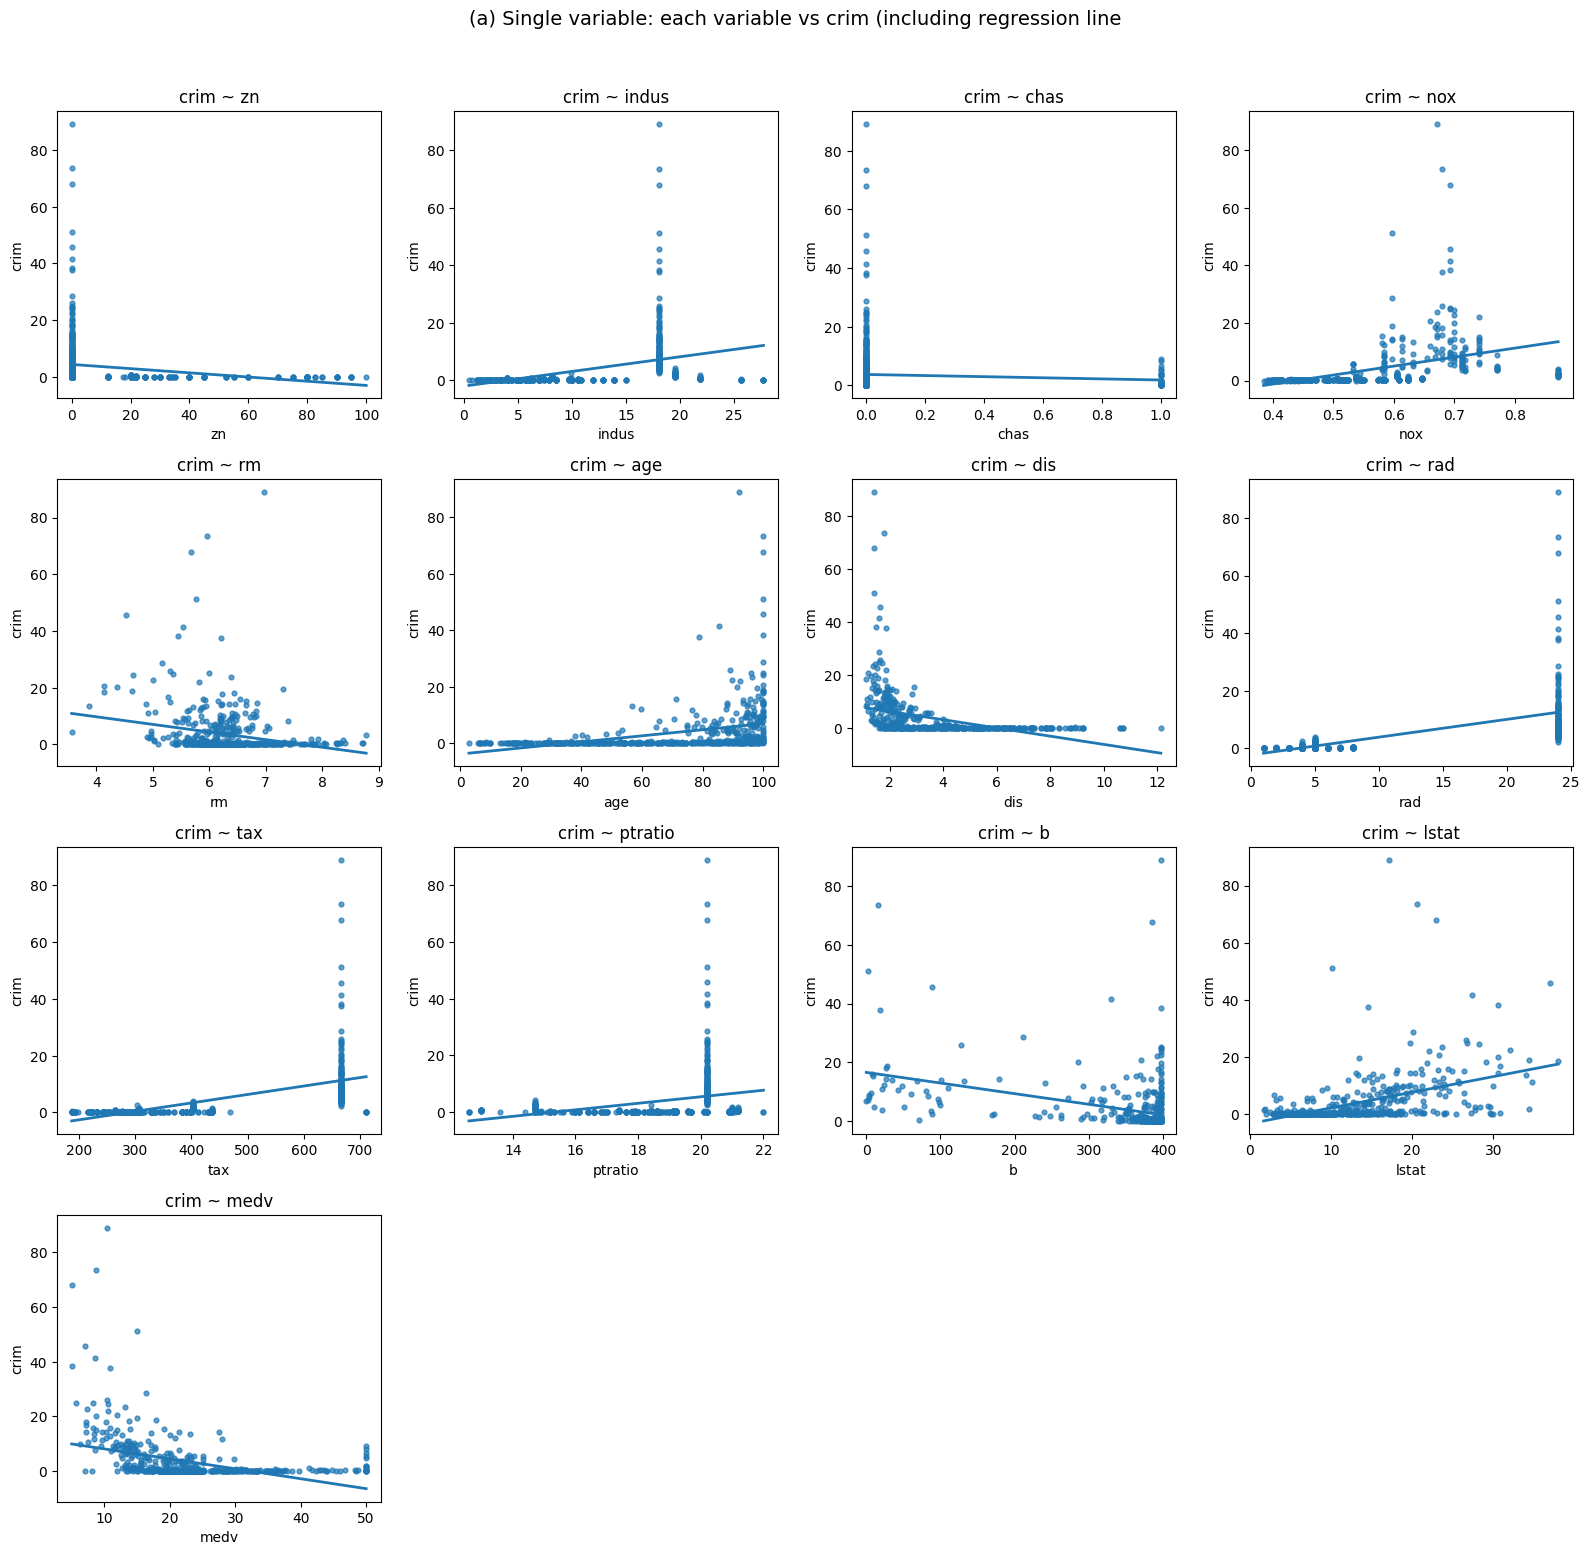

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
from textwrap import wrap

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

y = "crim"
X_all = [c for c in df.columns if c != y]

print("Data Dimension：", df.shape)
print("Column：", list(df.columns))

def regline(ax, x, y):
    x = np.asarray(x); y = np.asarray(y)
    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]; y = y[mask]
    if len(x) < 2:
        return
    b1, b0 = np.polyfit(x, y, 1)
    xgrid = np.linspace(x.min(), x.max(), 100)
    yhat = b1*xgrid + b0
    ax.plot(xgrid, yhat, linewidth=2)

def title_wrap(ax, s, width=30):
    ax.set_title("\n".join(wrap(s, width)))

alpha = 0.05

uni_rows = []
for x in X_all:
    fit = smf.ols(f"{y} ~ {x}", data=df).fit()
    uni_rows.append({
        "predictor": x,
        "coef": fit.params[x],
        "p_value": fit.pvalues[x],
        "r_squared": fit.rsquared
    })
uni_df = pd.DataFrame(uni_rows).sort_values("p_value").reset_index(drop=True)

print("\n(a) Univariate regression results (from small to large p-values)")
display(uni_df)

n = len(X_all)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.8*nrows))
axes = axes.ravel()

for i, x in enumerate(X_all):
    ax = axes[i]
    ax.scatter(df[x], df[y], s=12, alpha=0.7)
    regline(ax, df[x], df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    title_wrap(ax, f"crim ~ {x}")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("(a) Single variable: each variable vs crim (including regression line", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj = 0?


In [3]:
formula_all = f"{y} ~ " + " + ".join(X_all)
fit_all = smf.ols(formula_all, data=df).fit()

print("\n(b) Summary of the multiple linear regression model (crim ~ .)")
print(fit_all.summary())

coefs = fit_all.params.drop("Intercept")
pvals = fit_all.pvalues.drop("Intercept")
multi_df = pd.DataFrame({"predictor": coefs.index, "beta_multi": coefs.values, "p_value": pvals.values})
multi_df["significant@0.05"] = multi_df["p_value"] < alpha
multi_df = multi_df.sort_values("p_value").reset_index(drop=True)

print("\n(b) Significance in the multivariate model (from small to large p-value)")
display(round(multi_df, 3))


(b) Summary of the multiple linear regression model (crim ~ .)
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     31.47
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           1.57e-56
Time:                        11:55:41   Log-Likelihood:                -1653.3
No. Observations:                 506   AIC:                             3335.
Df Residuals:                     492   BIC:                             3394.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

,predictor,beta_multi,p_value,significant@0.05
0,rad,0.588,0.000,True
1,dis,-0.987,0.001,True
2,medv,-0.199,0.001,True
3,zn,0.045,0.017,True
4,b,-0.008,0.041,True
5,nox,-10.314,0.051,False
6,lstat,0.126,0.096,False
7,ptratio,-0.271,0.147,False
8,indus,-0.064,0.444,False
9,tax,-0.004,0.464,False


(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.


(c) Coefficient comparison table (univariate vs. multivariate)


,predictor,beta_uni,beta_multi
0,rad,0.617911,0.588209
1,tax,0.029742,-0.003780
2,lstat,0.548805,0.126211
3,nox,31.248531,-10.313535
4,indus,0.509776,-0.063855
5,medv,-0.363160,-0.198887
6,b,-0.036280,-0.007538
7,dis,-1.550902,-0.987176
8,age,0.107786,0.001452
9,ptratio,1.151983,-0.271081


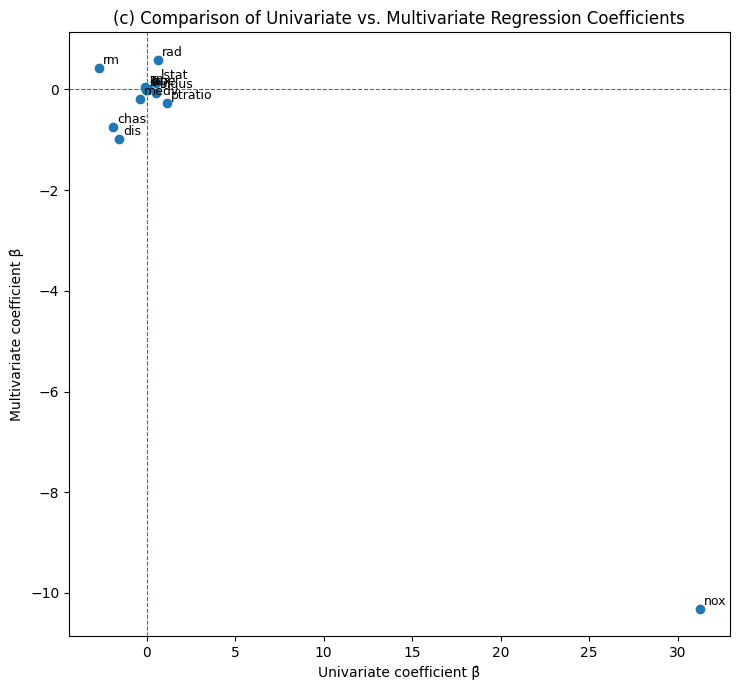

In [4]:
compare = uni_df[["predictor", "coef"]].rename(columns={"coef": "beta_uni"}).merge(
    multi_df[["predictor", "beta_multi"]], on="predictor", how="left"
)

print("\n(c) Coefficient comparison table (univariate vs. multivariate)")
display(compare)

plt.figure(figsize=(7.5, 7))
plt.axhline(0, linewidth=0.8, linestyle="--")
plt.axvline(0, linewidth=0.8, linestyle="--")
plt.plot(compare["beta_uni"], compare["beta_multi"], 'o')
for _, r in compare.iterrows():
    plt.annotate(r["predictor"], (r["beta_uni"], r["beta_multi"]), xytext=(3,3), textcoords="offset points", fontsize=9)
lims = plt.axis()
min_lim = min(lims[0], lims[2])
max_lim = max(lims[1], lims[3])
plt.xlabel("Univariate coefficient β̂")
plt.ylabel("Multivariate coefficient β̂")
plt.title("(c) Comparison of Univariate vs. Multivariate Regression Coefficients")
plt.tight_layout()
plt.show()


(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
Y = β0 + β1X + β2X2 + β3X3 + ".

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:2284: RuntimeWarning: invalid value encountered in scalar divide
  f_value = (ssr_restr - ssr_full) / df_diff / ssr_full * df_full



(d) Nonlinearity test (linear vs. cubic polynomial; the smaller p_nonlinear is, the more likely nonlinearity is present)


,predictor,p_nonlinear,r2_lin,r2_cub
0,medv,2.504778e-42,0.150780,0.420200
1,dis,3.071837e-19,0.144149,0.277825
2,nox,7.122383e-18,0.177217,0.296978
3,indus,8.408754e-14,0.165310,0.259658
4,age,4.125056e-07,0.124421,0.174231
5,tax,1.144238e-05,0.339614,0.368882
6,ptratio,2.541647e-04,0.084068,0.113782
7,rm,5.229427e-03,0.048069,0.067786
8,zn,8.511995e-03,0.040188,0.058242
9,rad,2.607832e-02,0.391257,0.400037


/tmp/ipython-input-2973180516.py:40: RankWarning: Polyfit may be poorly conditioned
  b3, b2, b1p, b0p = np.polyfit(xdat, ydat, 3)


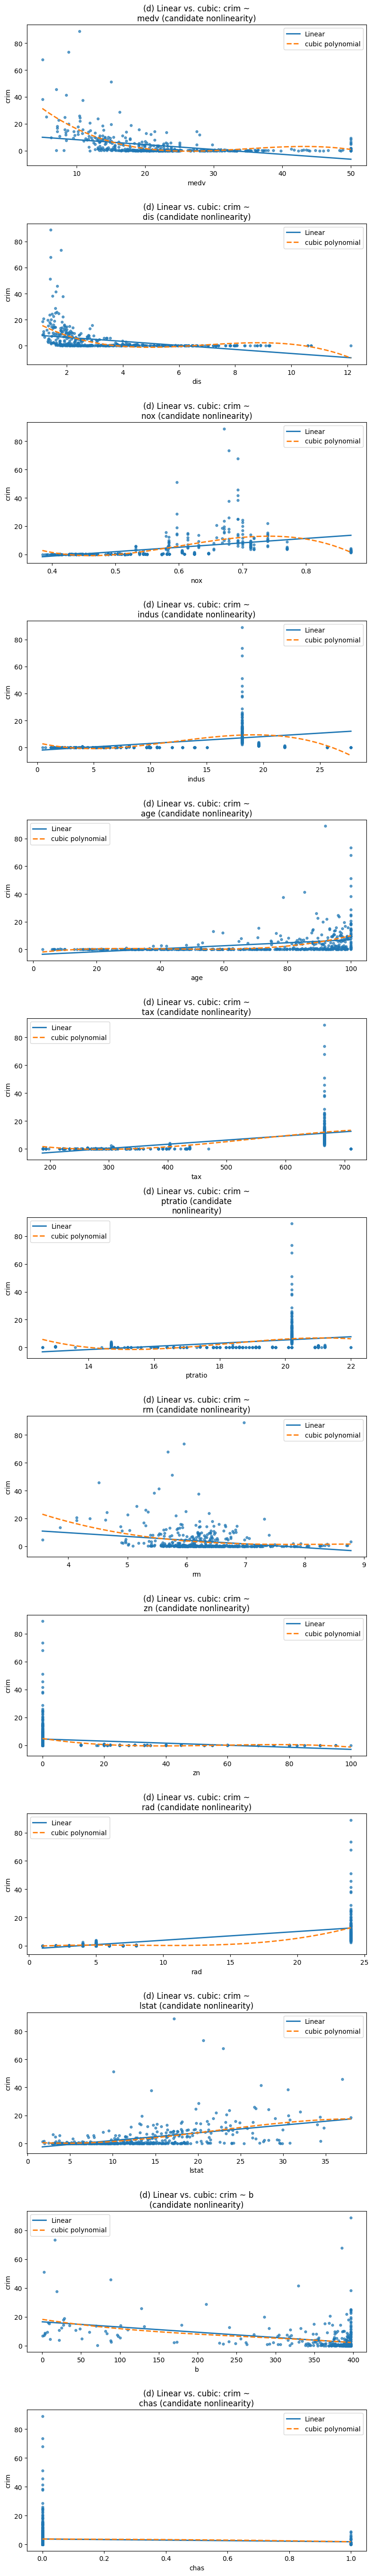

   predictor  r2_lin  r2_cub  p_nonlinear  nonlinear_significant
0       medv   0.151   0.420        0.000                   True
1        dis   0.144   0.278        0.000                   True
2        nox   0.177   0.297        0.000                   True
3      indus   0.165   0.260        0.000                   True
4        age   0.124   0.174        0.000                   True
5        tax   0.340   0.369        0.000                   True
6    ptratio   0.084   0.114        0.000                   True
7         rm   0.048   0.068        0.005                   True
8         zn   0.040   0.058        0.009                   True
9        rad   0.391   0.400        0.026                   True
10     lstat   0.208   0.218        0.037                   True
11         b   0.148   0.150        0.630                  False
12      chas   0.003   0.003          NaN                  False


In [8]:

nl_rows = []
for x in X_all:
    m1 = smf.ols(f"{y} ~ {x}", data=df).fit()
    df_tmp = df.copy()
    df_tmp[f"{x}_2"] = df_tmp[x]**2
    df_tmp[f"{x}_3"] = df_tmp[x]**3
    m3 = smf.ols(f"{y} ~ {x} + {x}_2 + {x}_3", data=df_tmp).fit()

    F, p, df_diff = m3.compare_f_test(m1)
    nl_rows.append({
        "predictor": x,
        "p_nonlinear": p,
        "r2_lin": m1.rsquared,
        "r2_cub": m3.rsquared
    })

nl_df = pd.DataFrame(nl_rows).sort_values("p_nonlinear").reset_index(drop=True)
print("\n(d) Nonlinearity test (linear vs. cubic polynomial; the smaller p_nonlinear is, the more likely nonlinearity is present)")
display(nl_df)


topk = 13
cands = nl_df["predictor"].head(topk).tolist()

fig, axes = plt.subplots(topk, 1, figsize=(8, 4.2*topk))
if topk == 1:
    axes = [axes]

for ax, x in zip(axes, cands):
    xdat = df[x].values
    ydat = df[y].values


    ax.scatter(xdat, ydat, s=12, alpha=0.7)

    b1, b0 = np.polyfit(xdat, ydat, 1)
    xgrid = np.linspace(xdat.min(), xdat.max(), 200)
    ax.plot(xgrid, b1*xgrid + b0, linewidth=2, label="Linear")

    b3, b2, b1p, b0p = np.polyfit(xdat, ydat, 3)
    ax.plot(xgrid, b3*xgrid**3 + b2*xgrid**2 + b1p*xgrid + b0p, linestyle="--", linewidth=2, label="cubic polynomial")
    title_wrap(ax, f"(d) Linear vs. cubic: crim ~ {x} (candidate nonlinearity)")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.legend()

plt.tight_layout()
plt.show()

nl_df["nonlinear_significant"] = nl_df["p_nonlinear"] < 0.05
nl_df = nl_df[["predictor", "r2_lin", "r2_cub", "p_nonlinear", "nonlinear_significant"]]
print(round(nl_df,3))
